In [60]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df=pd.read_excel('telcom_data.xlsx', sheet_name='Sheet1',
dtype={
    'MSISDN/Number': str,
    'IMEI': str,
    'IMSI': str,
    'Last Location Name': str
})
df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,...,Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,208201448079117,33664962239,35521209507511,9164566995485190,...,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,208201909211140,33681854413,35794009006359,L77566A,...,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,208200314458056,33760627129,35281510359387,D42335A,...,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,208201402342131,33750343200,35356610164913,T21824A,...,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,208201401415120,33699795932,35407009745539,D88865A,...,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [62]:
df.shape

(150001, 55)

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[us]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[us]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  str           
 7   MSISDN/Number                             148935 non-null  str           
 8   IMEI                                      149429 non-null  str           
 9   Last Location Name        

In [ ]:
df.describe().T

In [64]:
# Insights - 
# Data Overview and Cleaning
# In this section we will load the dataset, clean the column names, detect missing values, convert date columns to datetime, and fill numeric missing values using column means and categorical missing values using modes.

# We will also identify outliers and clean them so that downstream analysis is reliable.

In [ ]:
# Data Cleaning

In [65]:
# Convert column names to a standard Python-friendly format for easier use in code
# This replaces spaces, special characters, and symbols

df.columns = [c.strip().replace(' ', '_').replace('/', '_').replace('(', '').replace(')', '').replace('<', 'lt_').replace('>', 'gt_').replace('%', 'pct').replace('.', '').replace('-', '_') for c in df.columns] 

# Convert date columns to datetime so time-based analysis works correctly
for col in ['Start', 'End']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Identify numeric columns and report missing values
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_summary = df.isna().sum().sort_values(ascending=False).head(30)
print('Numeric columns count:', len(numeric_cols))
print('Missing values summary:')
print(missing_summary)

# Fill numeric missing values with the column mean
for col in numeric_cols:
    mean_value = df[col].mean()
    df[col] = df[col].fillna(mean_value)

# Fill categorical missing values with the column mode
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown')

# Replace extreme outliers beyond 3 standard deviations with the column mean
for col in numeric_cols:
    mean_val, std_val = df[col].mean(), df[col].std()
    if pd.notna(std_val) and std_val > 0:
        outlier_mask = (df[col] > mean_val + 3 * std_val) | (df[col] < mean_val - 3 * std_val)
        df.loc[outlier_mask, col] = mean_val

print(df.isna().sum().sort_values(ascending=False).head(20))
print('Cleaning complete. Missing values after clean:')

Numeric columns count: 46
Missing values summary:
Nb_of_sec_with_37500B_lt__Vol_UL                130254
Nb_of_sec_with_6250B_lt__Vol_UL_lt__37500B      111843
Nb_of_sec_with_125000B_lt__Vol_DL                97538
TCP_UL_Retrans_Vol_Bytes                         96649
Nb_of_sec_with_31250B_lt__Vol_DL_lt__125000B     93586
Nb_of_sec_with_1250B_lt__Vol_UL_lt__6250B        92894
Nb_of_sec_with_6250B_lt__Vol_DL_lt__31250B       88317
TCP_DL_Retrans_Vol_Bytes                         88146
HTTP_UL_Bytes                                    81810
HTTP_DL_Bytes                                    81474
Avg_RTT_DL_ms                                    27829
Avg_RTT_UL_ms                                    27812
Last_Location_Name                                1153
MSISDN_Number                                     1066
Nb_of_sec_with_Vol_UL_lt__1250B                    793
UL_TP_lt__10_Kbps_pct                              792
10_Kbps_lt__UL_TP_lt__50_Kbps_pct                  792
UL_TP_gt__300_K

C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\75741141.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


Start                                 1
End                                   1
Bearer_Id                             0
Start_ms                              0
End_ms                                0
Dur_ms                                0
IMSI                                  0
MSISDN_Number                         0
IMEI                                  0
Last_Location_Name                    0
Avg_RTT_DL_ms                         0
Avg_RTT_UL_ms                         0
Avg_Bearer_TP_DL_kbps                 0
Avg_Bearer_TP_UL_kbps                 0
TCP_DL_Retrans_Vol_Bytes              0
TCP_UL_Retrans_Vol_Bytes              0
DL_TP_lt__50_Kbps_pct                 0
50_Kbps_lt__DL_TP_lt__250_Kbps_pct    0
250_Kbps_lt__DL_TP_lt__1_Mbps_pct     0
DL_TP_gt__1_Mbps_pct                  0
dtype: int64
Cleaning complete. Missing values after clean:


In [86]:
print(df.columns)


Index(['MSISDN_Number', 'xdr_sessions', 'total_duration_ms',
       'total_traffic_bytes', 'session_frequency',
       'average_TCP_retransmission_bytes', 'average_RTT_ms',
       'average_throughput_kbps', 'handset_type', 'experience_cluster',
       'engagement_score', 'experience_score', 'satisfaction_score',
       'satisfaction_cluster'],
      dtype='str')


# USER OVERVIEW ANALYSIS

In [66]:
# Insights
# In this section, we identify the most popular handsets and handset manufacturers.

# Then we aggregate user-level session metrics to understand how many sessions, total duration, and traffic each user generated.

Handset_Type
Huawei B528S-23A                20324
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
undefined                        8987
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Name: count, dtype: int64


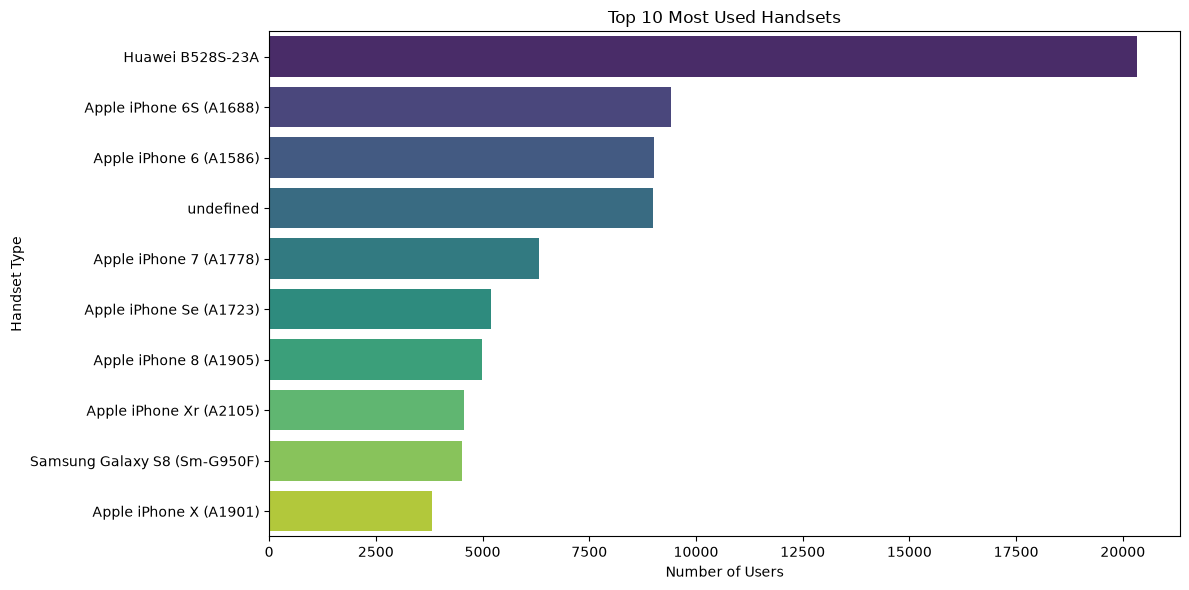

In [67]:
#TOP 10 HANDSET

top10 = df["Handset_Type"].value_counts().head(10)

print(top10)

# Plot

plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.values,
    y=top10.index,
    hue=top10.index,      # FutureWarning se bachne ke liye
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Used Handsets")
plt.xlabel("Number of Users")
plt.ylabel("Handset Type")

plt.tight_layout()
plt.show()

Handset_Manufacturer
Apple      60137
Samsung    40839
Huawei     34423
Name: count, dtype: int64


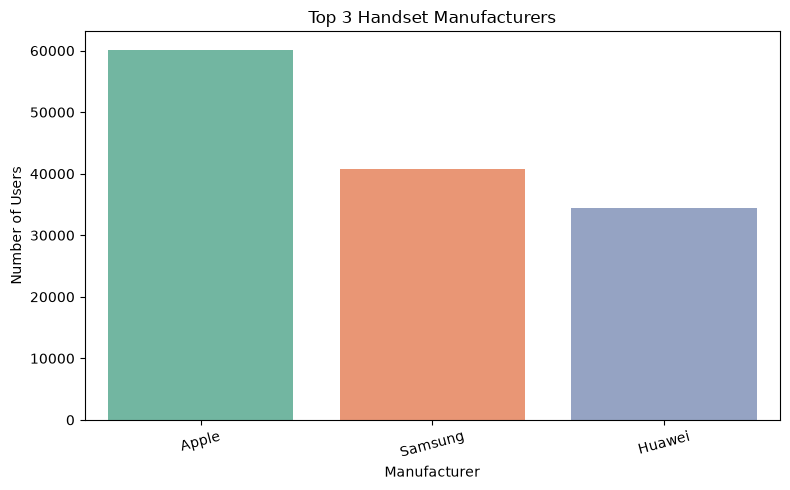

In [68]:
# Top 3 Handset Manufacturers

top3 = df["Handset_Manufacturer"].value_counts().head(3)

print(top3)

# Plot

plt.figure(figsize=(8,5))

sns.barplot(
    x=top3.index,
    y=top3.values,
    hue=top3.index,      # FutureWarning se bachne ke liye
    palette="Set2",
    legend=False
)

plt.title("Top 3 Handset Manufacturers")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Users")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

Top 3 Manufacturers:
['Apple', 'Samsung', 'Huawei']
Top 5 Handsets of Apple
Handset_Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\2578992558.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


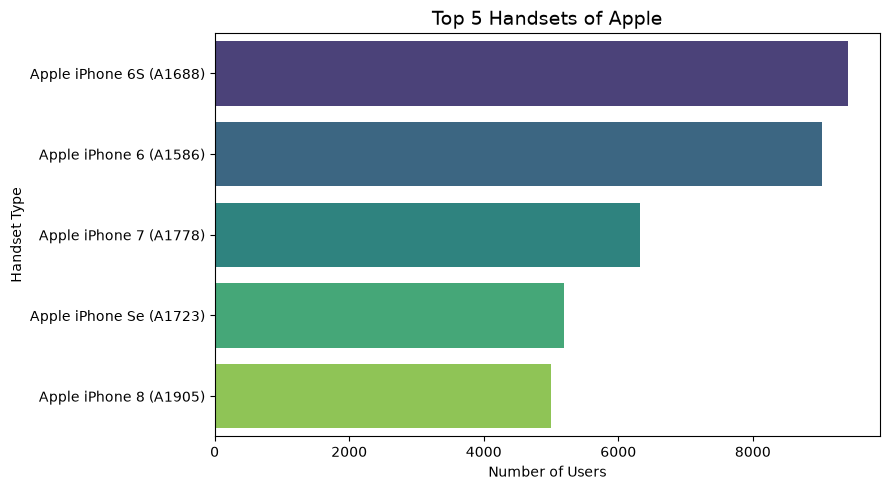

Top 5 Handsets of Samsung
Handset_Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    3199
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\2578992558.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


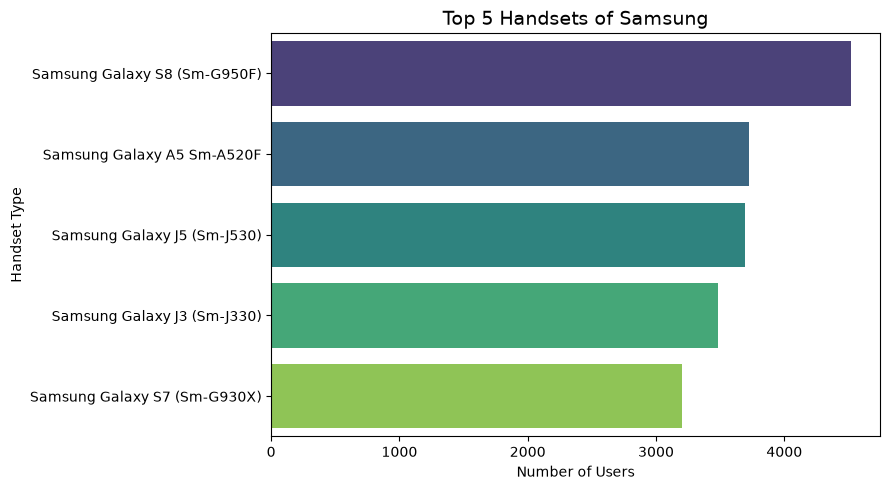

Top 5 Handsets of Huawei
Handset_Type
Huawei B528S-23A                  19752
Huawei E5180                       2079
Huawei P20 Lite Huawei Nova 3E     2021
Huawei P20                         1480
Huawei Y6 2018                      997
Name: count, dtype: int64


C:\Users\ashwi\AppData\Local\Temp\ipykernel_7636\2578992558.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


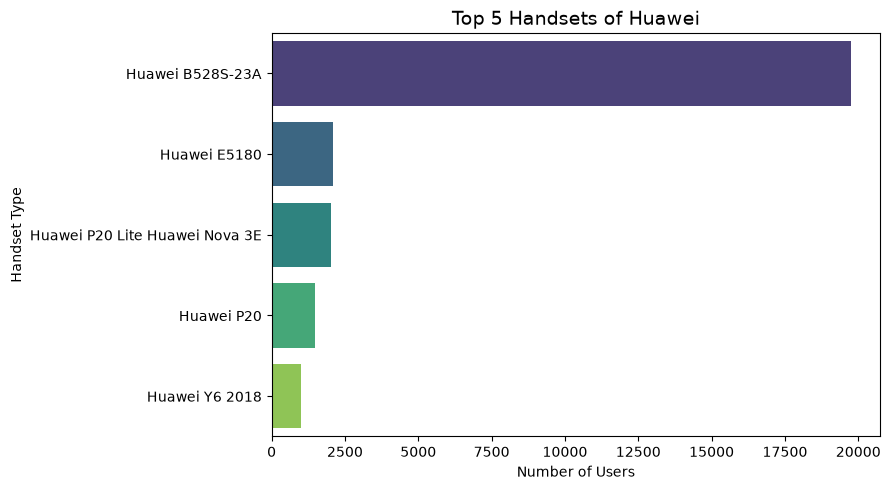

In [69]:

# Top 3 Handset Manufacturers

top3 = df["Handset_Manufacturer"].value_counts().head(3).index.tolist()

print("Top 3 Manufacturers:")
print(top3)

# Top 5 Handsets of each Manufacturer

for company in top3:

    print("="*60)
    print(f"Top 5 Handsets of {company}")

    top5 = (
        df[df["Handset_Manufacturer"] == company]
        ["Handset_Type"]
        .value_counts()
        .head(5)
    )

    print(top5)

    # Graph
    plt.figure(figsize=(9,5))

    sns.barplot(
        x=top5.values,
        y=top5.index,
        palette="viridis"
    )

    plt.title(f"Top 5 Handsets of {company}", fontsize=14)
    plt.xlabel("Number of Users")
    plt.ylabel("Handset Type")

    plt.tight_layout()
    plt.show()

In [70]:
# User-level aggregation: group by MSISDN and compute session and traffic metrics
application_cols = [
    'Social_Media_DL_Bytes', 'Social_Media_UL_Bytes',
    'Google_DL_Bytes', 'Google_UL_Bytes',
    'Email_DL_Bytes', 'Email_UL_Bytes',
    'Youtube_DL_Bytes', 'Youtube_UL_Bytes',
    'Netflix_DL_Bytes', 'Netflix_UL_Bytes',
    'Gaming_DL_Bytes', 'Gaming_UL_Bytes',
    'Other_DL_Bytes', 'Other_UL_Bytes'
]

# Set the user identifier and calculate total bytes
user_id = 'MSISDN_Number' if 'MSISDN_Number' in df.columns else 'MSISDN_Number'
df['Total_DL_UL_Bytes'] = df['Total_UL_Bytes'] + df['Total_DL_Bytes']
aggregates = df.groupby(user_id).agg(
    xdr_sessions=('Bearer_Id','count'),
    total_duration_ms=('Dur_ms','sum'),
    total_UL_bytes=('Total_UL_Bytes','sum'),
    total_DL_bytes=('Total_DL_Bytes','sum'),
    total_traffic_bytes=('Total_DL_UL_Bytes','sum')
)

# Add application-level totals if those columns exist
for col in application_cols:
    if col in df.columns:
        aggregates[col] = df.groupby(user_id)[col].sum()

aggregates = aggregates.reset_index()
aggregates.head()

,MSISDN_Number,xdr_sessions,total_duration_ms,total_UL_bytes,total_DL_bytes,total_traffic_bytes,Social_Media_DL_Bytes,Social_Media_UL_Bytes,Google_DL_Bytes,Google_UL_Bytes,Email_DL_Bytes,Email_UL_Bytes,Youtube_DL_Bytes,Youtube_UL_Bytes,Netflix_DL_Bytes,Netflix_UL_Bytes,Gaming_DL_Bytes,Gaming_UL_Bytes,Other_DL_Bytes,Other_UL_Bytes
0,3197020876596,1,104608.560347,37295915.0,194828056.0,232123971.0,668596.0,46628.0,8572779.0,1865881.0,842279.0,678492.0,9839889.0,2120016.0,10340908.0,16251392.0,164563605.0,13485133.0,467678100.0,2848373.0
1,33601001722,1,116720.000000,36053108.0,842637466.0,878690574.0,2206504.0,25631.0,3337123.0,1051882.0,837400.0,493962.0,14900201.0,6724347.0,10265105.0,16915876.0,811091133.0,1367528.0,377096990.0,9473882.0
2,33601001754,1,181230.000000,36104459.0,120755184.0,156859643.0,2598548.0,62017.0,4197697.0,1137166.0,2828821.0,478960.0,5324251.0,7107972.0,770569.0,10451194.0,105035298.0,14714780.0,279557701.0,2152370.0
3,33601002511,1,134969.000000,39306820.0,556659663.0,595966483.0,3148004.0,47619.0,3343483.0,99643.0,2436500.0,768880.0,2137272.0,19196298.0,16525919.0,2827981.0,529068485.0,9759228.0,495086501.0,6607171.0
4,33601007832,1,49878.000000,20327526.0,401993172.0,422320698.0,251469.0,28825.0,5937765.0,3740728.0,2178618.0,106052.0,4393123.0,2584198.0,1157362.0,784730.0,388074835.0,3051292.0,25248001.0,10031701.0


# USER ENGAGEMENT ANALYSIS

In [71]:
#Insights -
# Here we aggregate user engagement metrics, normalize them, and apply k-means clustering to segment users.

# This helps identify high-engagement and low-engagement user groups.

In [72]:
# Engagement metrics per customer
engagement_metrics = aggregates[[user_id, 'xdr_sessions', 'total_duration_ms', 'total_traffic_bytes']].copy()
engagement_metrics['session_frequency'] = engagement_metrics['xdr_sessions']

scaler = MinMaxScaler()
eng_cols = ['session_frequency', 'total_duration_ms', 'total_traffic_bytes']
engagement_norm = scaler.fit_transform(engagement_metrics[eng_cols])
engagement_norm_df = pd.DataFrame(engagement_norm, columns=[f'{c}_norm' for c in eng_cols])
engagement_norm_df[user_id] = engagement_metrics[user_id].values

# k-means clustering with k = 3
kmeans_eng = KMeans(n_clusters=3, random_state=42, n_init=10)
engagement_norm_df['engagement_cluster'] = kmeans_eng.fit_predict(engagement_norm)

cluster_stats = engagement_norm_df.groupby('engagement_cluster')[[f'{c}_norm' for c in eng_cols]].agg(['min', 'max', 'mean', 'sum'])
cluster_stats.columns = ['_'.join(col) for col in cluster_stats.columns]
print('Engagement cluster summary:')
print(cluster_stats)


Engagement cluster summary:
                    session_frequency_norm_min  session_frequency_norm_max  \
engagement_cluster                                                           
0                                          0.0                    0.002770   
1                                          1.0                    1.000000   
2                                          0.0                    0.014774   

                    session_frequency_norm_mean  session_frequency_norm_sum  \
engagement_cluster                                                            
0                                      0.000173                   16.257618   
1                                      1.000000                    1.000000   
2                                      0.001779                   22.580794   

                    total_duration_ms_norm_min  total_duration_ms_norm_max  \
engagement_cluster                                                           
0                            

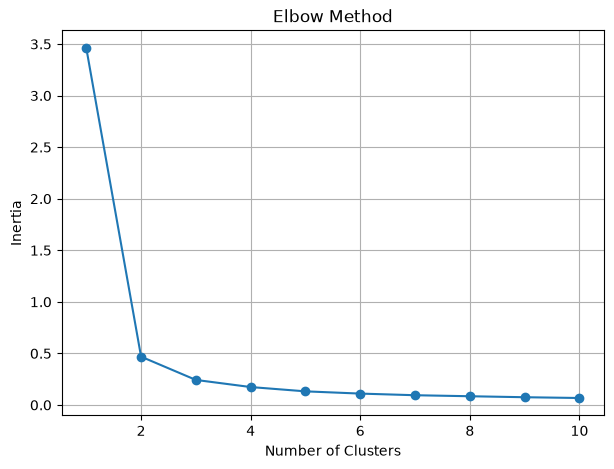

In [73]:
#  Elbow Method

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(engagement_norm)

    inertia.append(model.inertia_)

plt.figure(figsize=(7,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [74]:
#  Silhouette Score


score = silhouette_score(
    engagement_norm,
    engagement_norm_df["engagement_cluster"]
)

print("\nSilhouette Score :", round(score,3))


KMeans Clustering Completed

Silhouette Score : 0.646


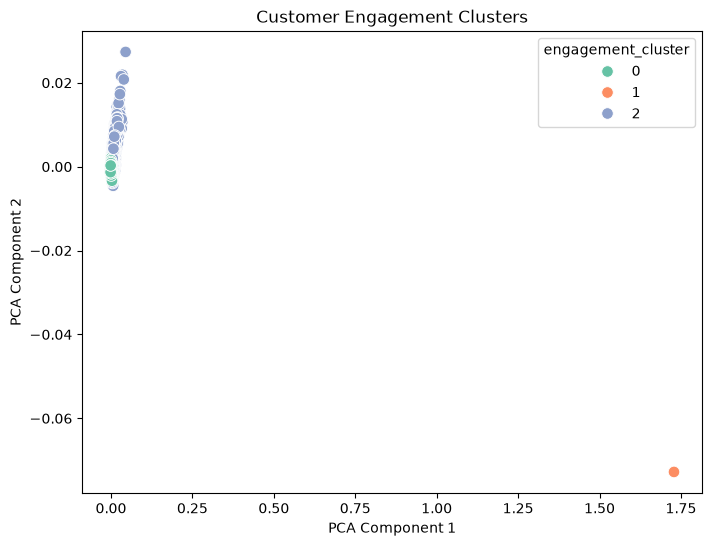

In [75]:
#  PCA Visualization

pca = PCA(
    n_components=2,
    random_state=42
)

engagement_pca = pca.fit_transform(
    engagement_norm
)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=engagement_pca[:,0],
    y=engagement_pca[:,1],
    hue=engagement_norm_df["engagement_cluster"],
    palette="Set2",
    s=70
)

plt.title("Customer Engagement Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()


Silhouette score for engagement clusters: 0.6460521788645037


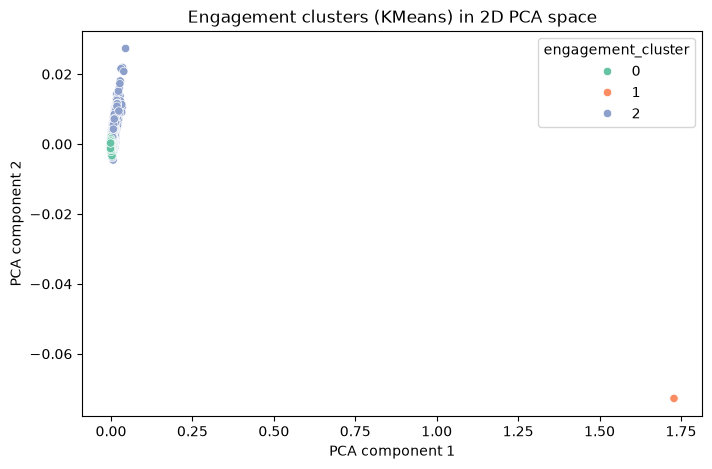

Aggregates with engagement cluster labels:
   MSISDN_Number  engagement_cluster
0  3197020876596                   0
1    33601001722                   0
2    33601001754                   0
3    33601002511                   0
4    33601007832                   0


In [76]:
# Task 2a: Unsupervised learning example on engagement data
from sklearn.metrics import silhouette_score

# Evaluate cluster quality using the silhouette score
sil_score = silhouette_score(engagement_norm, engagement_norm_df['engagement_cluster'])
print('Silhouette score for engagement clusters:', sil_score)

# Create a 2D cluster visualization using PCA
engagement_pca = PCA(n_components=2, random_state=42).fit_transform(engagement_norm)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=engagement_pca[:, 0],
    y=engagement_pca[:, 1],
    hue=engagement_norm_df['engagement_cluster'],
    palette='Set2',
    legend='full'
)
plt.title('Engagement clusters (KMeans) in 2D PCA space')
plt.xlabel('PCA component 1')
plt.ylabel('PCA component 2')
plt.show()

# Merge cluster labels into aggregates so they can be used later
if user_id in aggregates.columns:
    aggregates = aggregates.merge(
        engagement_norm_df[[user_id, 'engagement_cluster']],
        on=user_id,
        how='left'
    )
    print('Aggregates with engagement cluster labels:')
    print(aggregates[[user_id, 'engagement_cluster']].head())
else:
    print('Warning: user identifier column not found in aggregates.')

# Experience Analytics

In [77]:
# Insights -
# In this section, we aggregate network performance metrics like retransmission, RTT, and throughput on a per-user basis.

# Then we identify top and bottom users and use k-means clustering to create experience-based groups.

In [82]:
# Prepare experience metrics and calculate user-wise average network performance
experience_cols = [
    'TCP_DL_Retrans_Vol_Bytes', 'TCP_UL_Retrans_Vol_Bytes',
    'Avg_RTT_DL_ms', 'Avg_RTT_UL_ms',
    'Avg_Bearer_TP_DL_kbps', 'Avg_Bearer_TP_UL_kbps',
    'Handset_Type'
]

if 'df' not in globals():
    raise NameError('DataFrame df is not defined. Run the dataset loading cell first.')
if 'user_id' not in globals():
    raise NameError('user_id is not defined. Run Task 1 before Task 3.')

required_cols = [
    'TCP_DL_Retrans_Vol_Bytes', 'Avg_RTT_DL_ms', 'Avg_Bearer_TP_DL_kbps', 'Handset_Type'
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns for experience analysis: {missing_cols}')

# Calculate average network performance per user
experience_summary = df.groupby(user_id).agg(
    average_TCP_retransmission_bytes=('TCP_DL_Retrans_Vol_Bytes', 'mean'),
    average_RTT_ms=('Avg_RTT_DL_ms', 'mean'),
    average_throughput_kbps=('Avg_Bearer_TP_DL_kbps', 'mean'),
    handset_type=('Handset_Type', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
).reset_index()

# View top and bottom users for each experience metric
for metric in ['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps']:
    print(f'--- Top 10 users by {metric} ---')
    print(experience_summary.nlargest(10, metric)[[user_id, metric]].to_string(index=False))
    print(f'--- Bottom 10 users by {metric} ---')
    print(experience_summary.nsmallest(10, metric)[[user_id, metric]].to_string(index=False))

# View throughput and TCP retransmission distribution by handset type
throughput_by_handset = experience_summary.groupby('handset_type')['average_throughput_kbps'].describe()
tcp_by_handset = experience_summary.groupby('handset_type')['average_TCP_retransmission_bytes'].describe()
print('Throughput distribution by handset type:')
print(throughput_by_handset.head(10))
print('TCP retransmission distribution by handset type:')
print(tcp_by_handset.head(10))

# Cluster experience data to identify different experience groups
exp_features = experience_summary[['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps']].fillna(0)
exp_norm = StandardScaler().fit_transform(exp_features)

kmeans_exp = KMeans(n_clusters=3, random_state=42, n_init=10)
experience_summary['experience_cluster'] = kmeans_exp.fit_predict(exp_norm)

# Calculate cluster centroids (mean values per cluster)
experience_labels = experience_summary.groupby('experience_cluster')[[
    'average_TCP_retransmission_bytes',
    'average_RTT_ms',
    'average_throughput_kbps'
]].mean()


print("Experience cluster centroids:")
print(experience_labels)

--- Top 10 users by average_TCP_retransmission_bytes ---
MSISDN_Number  average_TCP_retransmission_bytes
  33665011274                       367686534.0
  33665370471                       365950245.0
  33761797502                       363750572.0
  33648864136                       362128467.0
  33665188241                       353206167.0
  33668151639                       351440959.0
  33658489664                       348062089.0
  33667141136                       345341458.0
  33650107786                       344820925.0
  33631835065                       339178976.0
--- Bottom 10 users by average_TCP_retransmission_bytes ---
MSISDN_Number  average_TCP_retransmission_bytes
  33664535559                               2.0
  33761543605                               2.0
  33669309035                               4.0
  33669328368                               4.0
  33699002991                               4.0
  33699060950                               4.0
  33761506920      

# 4. SATISFACTION ANALYSIS

In [ ]:
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Define base path for saving outputs
base = Path('C:/dataset1')   # adjust if needed

# Experience Metrics
experience_cols = [
    'TCP_DL_Retrans_Vol_Bytes', 'TCP_UL_Retrans_Vol_Bytes',
    'Avg_RTT_DL_ms', 'Avg_RTT_UL_ms',
    'Avg_Bearer_TP_DL_kbps', 'Avg_Bearer_TP_UL_kbps',
    'Handset_Type'
]

required_cols = [
    'TCP_DL_Retrans_Vol_Bytes', 'Avg_RTT_DL_ms', 'Avg_Bearer_TP_DL_kbps', 'Handset_Type'
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns for experience analysis: {missing_cols}')

experience_summary = df.groupby(user_id).agg(
    average_TCP_retransmission_bytes=('TCP_DL_Retrans_Vol_Bytes', 'mean'),
    average_RTT_ms=('Avg_RTT_DL_ms', 'mean'),
    average_throughput_kbps=('Avg_Bearer_TP_DL_kbps', 'mean'),
    handset_type=('Handset_Type', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Cluster experience data
exp_features = experience_summary[['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps']].fillna(0)
exp_norm = StandardScaler().fit_transform(exp_features)
kmeans_exp = KMeans(n_clusters=3, random_state=42, n_init=10)
experience_summary['experience_cluster'] = kmeans_exp.fit_predict(exp_norm)

experience_labels = experience_summary.groupby('experience_cluster')[[
    'average_TCP_retransmission_bytes',
    'average_RTT_ms',
    'average_throughput_kbps'
]].mean()

print("Experience cluster centroids:")
print(experience_labels)

# Satisfaction Metrics
eng_cols = ['session_frequency', 'total_duration_ms', 'total_traffic_bytes']

satisfaction_df = engagement_metrics.merge(experience_summary, on=user_id, how='left')
satisfaction_df = satisfaction_df.dropna(subset=['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps'])

reference_engagement = engagement_metrics[eng_cols].min()
reference_experience = experience_summary[['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps']].min()

def euclidean_distance(row, ref):
    return np.linalg.norm(row - ref)

satisfaction_df['engagement_score'] = satisfaction_df[eng_cols].apply(
    lambda row: euclidean_distance(row.values.astype(float), reference_engagement.values.astype(float)), axis=1
)
satisfaction_df['experience_score'] = satisfaction_df[['average_TCP_retransmission_bytes', 'average_RTT_ms', 'average_throughput_kbps']].apply(
    lambda row: euclidean_distance(row.values.astype(float), reference_experience.values.astype(float)), axis=1
)
satisfaction_df['satisfaction_score'] = (satisfaction_df['engagement_score'] + satisfaction_df['experience_score']) / 2

print('Top 10 satisfied customers:')
print(satisfaction_df.nlargest(10, 'satisfaction_score')[[user_id, 'engagement_score', 'experience_score', 'satisfaction_score']].to_string(index=False))

# Cluster satisfaction scores
satisfaction_norm = StandardScaler().fit_transform(satisfaction_df[['engagement_score', 'experience_score']])
kmeans_satisfaction = KMeans(n_clusters=2, random_state=42, n_init=10)
satisfaction_df['satisfaction_cluster'] = kmeans_satisfaction.fit_predict(satisfaction_norm)

summary_by_cluster = satisfaction_df.groupby('satisfaction_cluster')[['engagement_score', 'experience_score', 'satisfaction_score']].mean()
print('Satisfaction cluster averages:')
print(summary_by_cluster)

print('Cluster counts:')
print(satisfaction_df['satisfaction_cluster'].value_counts())

# Satisfaction graphs
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=satisfaction_df,
    x='engagement_score',
    y='experience_score',
    hue='satisfaction_cluster',
    palette='Set2',
    s=80
)
plt.title('Satisfaction Clusters: Engagement vs Experience')
plt.xlabel('Engagement Score')
plt.ylabel('Experience Score')
plt.legend(title='Satisfaction Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(
    data=summary_by_cluster.reset_index(),
    x='satisfaction_cluster',
    y='satisfaction_score',
    palette='viridis'
)
plt.title('Average Satisfaction Score by Cluster')
plt.xlabel('Satisfaction Cluster')
plt.ylabel('Mean Satisfaction Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(
    data=satisfaction_df,
    x='satisfaction_score',
    bins=30,
    kde=True,
    color='steelblue'
)
plt.title('Distribution of Satisfaction Scores')
plt.xlabel('Satisfaction Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Save Final Output
output_path = base / 'final_user_satisfaction.csv'
satisfaction_df.to_csv(output_path, index=False)
print('Saved final table to', output_path)


Experience cluster centroids:
                    average_TCP_retransmission_bytes  average_RTT_ms  \
experience_cluster                                                     
0                                       1.800930e+07       73.710127   
1                                       6.713068e+06       74.814334   
2                                       7.677011e+06      841.650826   

                    average_throughput_kbps  
experience_cluster                           
0                               2541.970345  
1                              36261.125379  
2                               7259.090204  
Top 10 satisfied customers:
MSISDN_Number  engagement_score  experience_score  satisfaction_score
  33626320676      5.396826e+11      9.830333e+06        2.698462e+11
  33614892860      8.812978e+09      7.540140e+06        4.410259e+09
  33760536639      8.481525e+09      1.616105e+07        4.248843e+09
  33625779332      8.466372e+09      1.470700e+07        4.240539e+09
 

# Regression Model

Dataset Loaded Successfully
   MSISDN_Number  xdr_sessions  total_duration_ms  total_traffic_bytes  \
0  3197020876596             1      104608.560347          232123971.0   
1    33601001722             1      116720.000000          878690574.0   
2    33601001754             1      181230.000000          156859643.0   
3    33601002511             1      134969.000000          595966483.0   
4    33601007832             1       49878.000000          422320698.0   

   session_frequency  average_TCP_retransmission_bytes  average_RTT_ms  \
0                  1                      2.080991e+07      109.795706   
1                  1                      2.080991e+07       46.000000   
2                  1                      2.080991e+07       30.000000   
3                  1                      2.080991e+07      109.795706   
4                  1                      1.066000e+03       69.000000   

   average_throughput_kbps                      handset_type  \
0                 

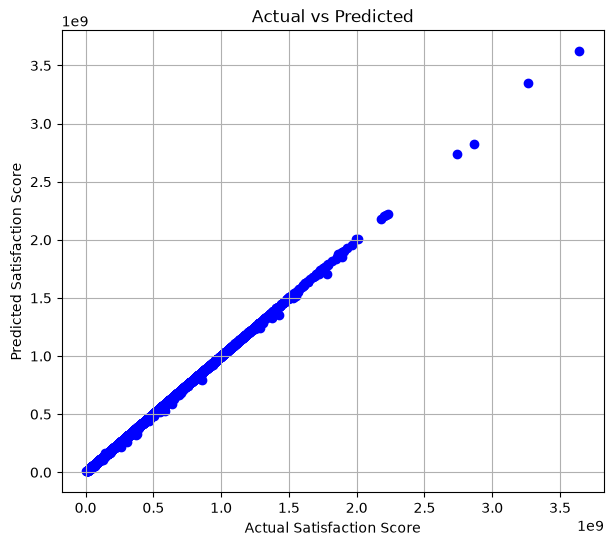


Feature Importance
                            Feature  Importance
2               total_traffic_bytes    0.752739
0                 session_frequency    0.127422
1                 total_duration_ms    0.119459
3  average_TCP_retransmission_bytes    0.000363
4                    average_RTT_ms    0.000009
5           average_throughput_kbps    0.000009


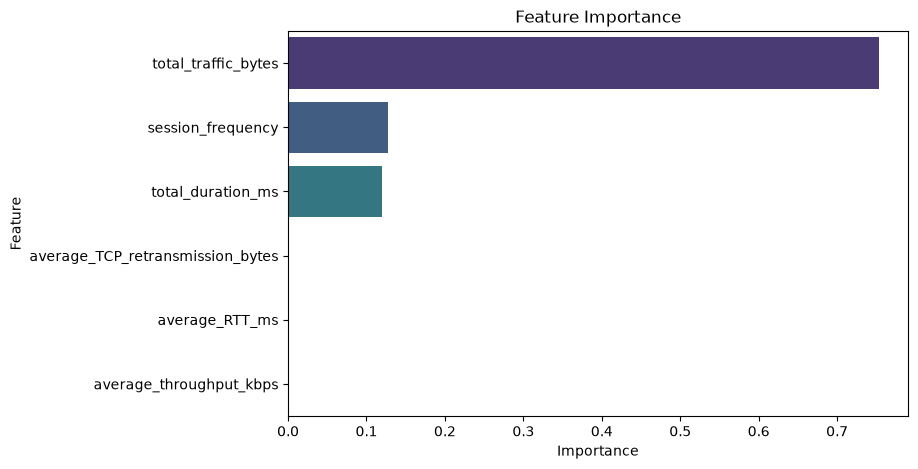


Model Saved Successfully

Predicted Satisfaction Score
[4.33556137e+08]
NOTEBOOK 6 COMPLETED SUCCESSFULLY


In [ ]:

# SATISFACTION SCORE PREDICTION
# Random Forest Regression

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib


#  Load Dataset


df = pd.read_csv("final_user_satisfaction.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print(df.head())
#  Dataset Shape


print("\nDataset Shape")

print(df.shape)


#  Select Features


features = [

    "session_frequency",

    "total_duration_ms",

    "total_traffic_bytes",

    "average_TCP_retransmission_bytes",

    "average_RTT_ms",

    "average_throughput_kbps"

]

target = "satisfaction_score"


#  Create X and y


X = df[features]

y = df[target]

print("\nFeatures")

print(X.head())

print("\nTarget")

print(y.head())

# 6. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("\nTraining Shape")

print(X_train.shape)

print("\nTesting Shape")

print(X_test.shape)


# 7. Build Model


model = RandomForestRegressor(

    n_estimators=200,

    random_state=42

)

# Train Model


model.fit(

    X_train,

    y_train

)

print("\nModel Training Completed")


#  Prediction


y_pred = model.predict(

    X_test

)


#  Evaluation


mae = mean_absolute_error(

    y_test,

    y_pred

)

mse = mean_squared_error(

    y_test,

    y_pred

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    y_pred

)

print("="*60)

print("MODEL PERFORMANCE")

print("="*60)

print("MAE  :", mae)

print("MSE  :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)


# Actual vs Predicted

result = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})

print(result.head(20))


#  Scatter Plot


plt.figure(figsize=(7,6))

plt.scatter(

    y_test,

    y_pred,

    color="blue"

)

plt.xlabel("Actual Satisfaction Score")

plt.ylabel("Predicted Satisfaction Score")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

#  Feature Importance


importance = pd.DataFrame({

    "Feature":features,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nFeature Importance")

print(importance)

plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    hue="Feature",

    palette="viridis",

    legend=False

)

plt.title("Feature Importance")

plt.show()


#  Save Model


joblib.dump(

    model,

    "telecom_satisfaction_model.pkl"

)

print("\nModel Saved Successfully")

#  Predict New Customer

sample = pd.DataFrame({

    "session_frequency":[20],

    "total_duration_ms":[800000],

    "total_traffic_bytes":[900000000],

    "average_TCP_retransmission_bytes":[45000],

    "average_RTT_ms":[60],

    "average_throughput_kbps":[25000]

})

prediction = model.predict(

    sample

)

print("\nPredicted Satisfaction Score")

print(prediction)


#  Finish


print("="*60)

print("NOTEBOOK 6 COMPLETED SUCCESSFULLY")

print("="*60)

regression_result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

regression_result.to_csv("regression_result.csv", index=False)

# MYSQL

In [ ]:

#  EXPORT DATA TO MYSQL
import mysql.connector
print("Connected")

Connected


In [ ]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Pathanaksa29@",
    database="telecom1_project"
)

print("✅ MySQL Connected Successfully")

✅ MySQL Connected Successfully


In [ ]:
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS user_satisfaction (

    MSISDN_Number VARCHAR(30),

    engagement_score DOUBLE,

    experience_score DOUBLE,

    satisfaction_score DOUBLE

)
""")

conn.commit()

print("✅ Table Created Successfully")

✅ Table Created Successfully


In [ ]:
cursor = conn.cursor()

sql = """
INSERT INTO user_satisfaction
(
    MSISDN_Number,
    engagement_score,
    experience_score,
    satisfaction_score
)
VALUES (%s, %s, %s, %s)
"""

for _, row in satisfaction_df.iterrows():

    cursor.execute(
        sql,
        (
            str(row["MSISDN_Number"]),
            float(row["engagement_score"]),
            float(row["experience_score"]),
            float(row["satisfaction_score"])
        )
    )

conn.commit()

print("✅ Data Inserted Successfully")

✅ Data Inserted Successfully


In [ ]:
import pandas as pd

df = pd.read_csv("final_user_satisfaction.csv")

df.to_sql(
    "user_satisfaction",
    engine,
    if_exists="replace",
    index=False
)

print("Data Uploaded Successfully")

Data Uploaded Successfully


In [ ]:
# Drop duplicate (_x) columns
dashboard_df = dashboard_df.drop(columns=[
    "youtube_usage_x",
    "netflix_usage_x",
    "google_usage_x",
    "gaming_usage_x",
    "email_usage_x",
    "social_media_usage_x",
    "handset_type_x"
])

# Rename (_y) columns
dashboard_df = dashboard_df.rename(columns={
    "youtube_usage_y": "youtube_usage",
    "netflix_usage_y": "netflix_usage",
    "google_usage_y": "google_usage",
    "gaming_usage_y": "gaming_usage",
    "email_usage_y": "email_usage",
    "social_media_usage_y": "social_media_usage",
    "handset_type_y": "handset_type"
})

# DASHBOARD